# Phase 1 — Exploratory Data Analysis
## Local Train Crowd-Level Prediction — Mumbai Harbour Line

This notebook explores the synthetic `harbour_line_ridership` dataset generated by
`src/data_generation/generate_dataset.py`. Every modeling assumption behind these
numbers is documented in [`DATA_GENERATION.md`](../DATA_GENERATION.md) — this
notebook checks that the generator actually produced the patterns it was designed to
produce, and gives a first look at the data that later phases (station clustering,
regression, asymmetric-loss classification) will build on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

REPORTS_DIR = "../reports/phase1"
import os
os.makedirs(REPORTS_DIR, exist_ok=True)

df = pd.read_parquet("../data/processed/harbour_line_ridership.parquet")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(1040250, 24)


,date,day_of_week,is_weekend,month,is_holiday,holiday_name,is_monsoon,is_mega_block_day,station_id,station_name,...,direction,hour,coach_type,rainfall_mm,temp_max_c,temp_min_c,temperature_c,rain_intensity_band,rain_regime,occupancy_pct
0,2023-01-01,Sunday,True,1,True,New Year's Day,False,False,S00,CSMT,...,UP,5,General,0.0,31.5,18.7,25.1,none,normal,14.5
1,2023-01-01,Sunday,True,1,True,New Year's Day,False,False,S00,CSMT,...,UP,5,Ladies,0.0,31.5,18.7,25.1,none,normal,16.2
2,2023-01-01,Sunday,True,1,True,New Year's Day,False,False,S00,CSMT,...,UP,5,First Class,0.0,31.5,18.7,25.1,none,normal,3.9
3,2023-01-01,Sunday,True,1,True,New Year's Day,False,False,S00,CSMT,...,DOWN,5,General,0.0,31.5,18.7,25.1,none,normal,11.1
4,2023-01-01,Sunday,True,1,True,New Year's Day,False,False,S00,CSMT,...,DOWN,5,Ladies,0.0,31.5,18.7,25.1,none,normal,14.3


## 1. Basic structure and data quality

In [2]:
print("Rows:", len(df))
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Stations:", df['station_id'].nunique())
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None")
df.dtypes

Rows: 1040250
Date range: 2023-01-01 to 2023-12-31
Stations: 25
Nulls per column:
None


date                   datetime64[us]
day_of_week                       str
is_weekend                       bool
month                           int32
is_holiday                       bool
holiday_name                      str
is_monsoon                       bool
is_mega_block_day                bool
station_id                        str
station_name                      str
station_order                   int64
distance_km                   float64
station_type                      str
is_interchange                   bool
direction                         str
hour                            int64
coach_type                        str
rainfall_mm                   float64
temp_max_c                    float64
temp_min_c                    float64
temperature_c                 float64
rain_intensity_band               str
rain_regime                       str
occupancy_pct                 float64
dtype: object

In [3]:
df[["occupancy_pct", "rainfall_mm", "temperature_c"]].describe()

,occupancy_pct,rainfall_mm,temperature_c
count,1.040250e+06,1.040250e+06,1.040250e+06
mean,3.344361e+01,7.926849e+00,2.723151e+01
std,3.149210e+01,2.033332e+01,1.676141e+00
min,0.000000e+00,0.000000e+00,2.330000e+01
25%,1.270000e+01,0.000000e+00,2.610000e+01
50%,2.540000e+01,0.000000e+00,2.730000e+01
75%,4.340000e+01,4.800000e+00,2.850000e+01
max,3.000000e+02,1.797000e+02,3.100000e+01


## 2. Occupancy distribution

Recall `occupancy_pct` is expressed as % of *rated* coach capacity, and is allowed to
exceed 100% — Mumbai's suburban trains are well documented to run at 2.5x-3x rated
capacity ("super-dense crush load") during peak hours. A value of 100% means "at rated
capacity", not "the maximum possible".

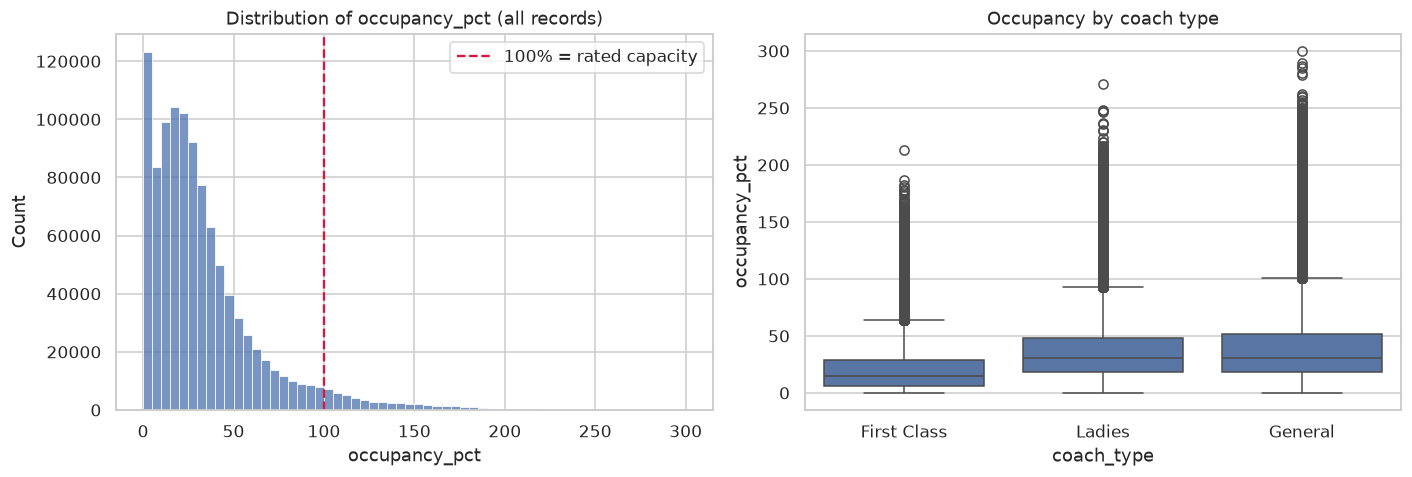

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["occupancy_pct"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].axvline(100, color="crimson", linestyle="--", label="100% = rated capacity")
axes[0].set_title("Distribution of occupancy_pct (all records)")
axes[0].set_xlabel("occupancy_pct")
axes[0].legend()

sns.boxplot(data=df, x="coach_type", y="occupancy_pct", ax=axes[1],
            order=["First Class", "Ladies", "General"])
axes[1].set_title("Occupancy by coach type")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/01_occupancy_distribution.png", bbox_inches="tight")
plt.show()

## 3. Daily shape: the AM/PM commute pattern

The core design of the simulator: a train travelling **UP** (towards CSMT, the CBD)
fills up progressively as it approaches CSMT in the morning; a **DOWN** train fills up
progressively as it moves away from CSMT in the evening. Averaging over all stations
and days should show two clear peaks.

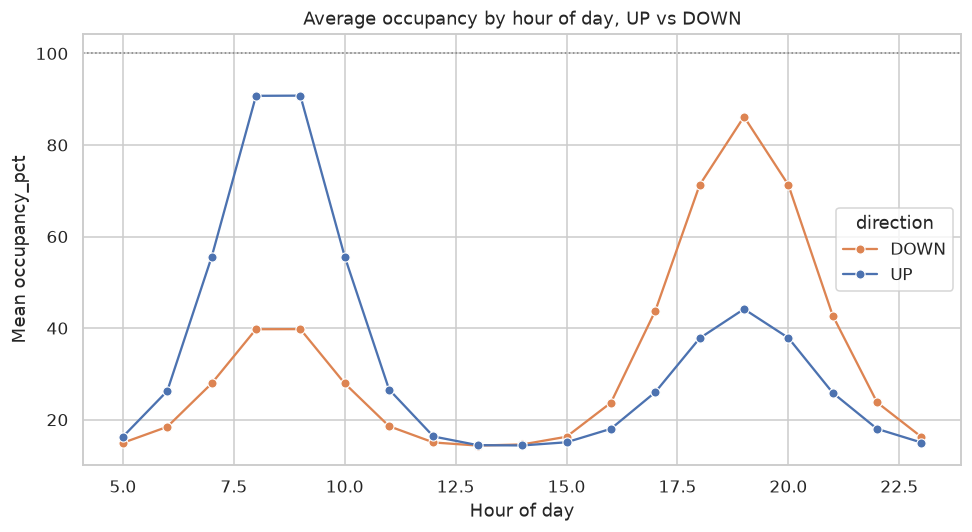

In [5]:
hourly = df.groupby(["hour", "direction"])["occupancy_pct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=hourly, x="hour", y="occupancy_pct", hue="direction",
             marker="o", ax=ax, palette={"UP": "#4C72B0", "DOWN": "#DD8452"})
ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.set_title("Average occupancy by hour of day, UP vs DOWN")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean occupancy_pct")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/02_hourly_pattern_by_direction.png", bbox_inches="tight")
plt.show()

## 4. Load buildup along the route

At the AM peak, a UP (CBD-bound) train should be most crowded near CSMT and least
crowded near Panvel — it has had the whole route to accumulate boarders. At the PM
peak, a DOWN train should show the mirror-image pattern.

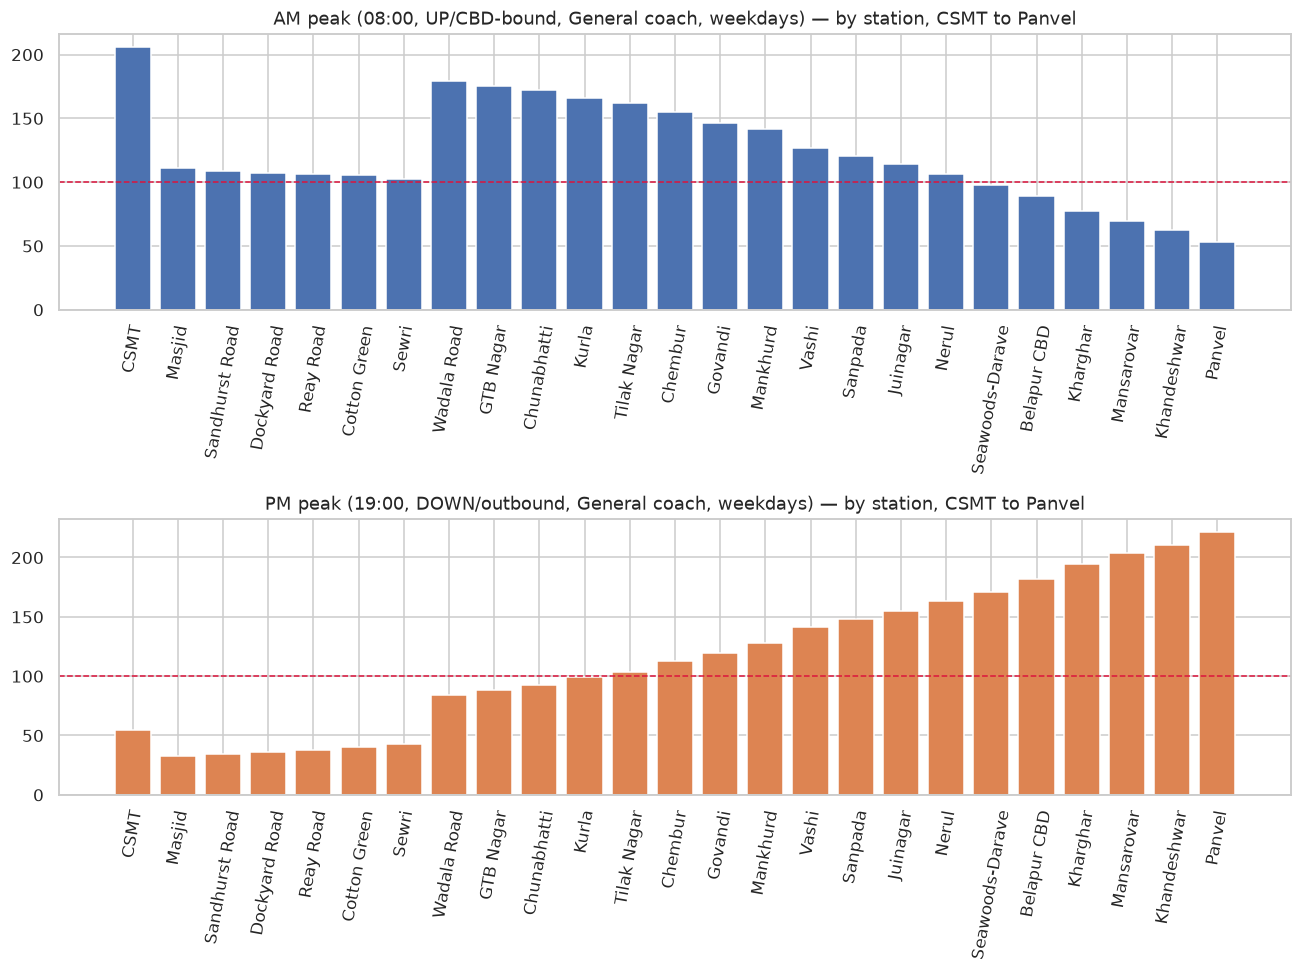

In [6]:
am_peak = df[(df.hour == 8) & (df.direction == "UP") & (df.coach_type == "General")
             & (~df.is_weekend) & (~df.is_holiday)]
pm_peak = df[(df.hour == 19) & (df.direction == "DOWN") & (df.coach_type == "General")
             & (~df.is_weekend) & (~df.is_holiday)]

am_by_station = am_peak.groupby(["station_order", "station_name"])["occupancy_pct"].mean().reset_index()
pm_by_station = pm_peak.groupby(["station_order", "station_name"])["occupancy_pct"].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

axes[0].bar(am_by_station["station_name"], am_by_station["occupancy_pct"], color="#4C72B0")
axes[0].set_title("AM peak (08:00, UP/CBD-bound, General coach, weekdays) — by station, CSMT to Panvel")
axes[0].tick_params(axis="x", rotation=80)
axes[0].axhline(100, color="crimson", linestyle="--", linewidth=1)

axes[1].bar(pm_by_station["station_name"], pm_by_station["occupancy_pct"], color="#DD8452")
axes[1].set_title("PM peak (19:00, DOWN/outbound, General coach, weekdays) — by station, CSMT to Panvel")
axes[1].tick_params(axis="x", rotation=80)
axes[1].axhline(100, color="crimson", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/03_load_buildup_by_station.png", bbox_inches="tight")
plt.show()

## 5. Station-type signatures

This is the diversity Phase 2's clustering is meant to discover: each `station_type`
should have a visibly different *shape* of ridership across the day, not just a
different scale.

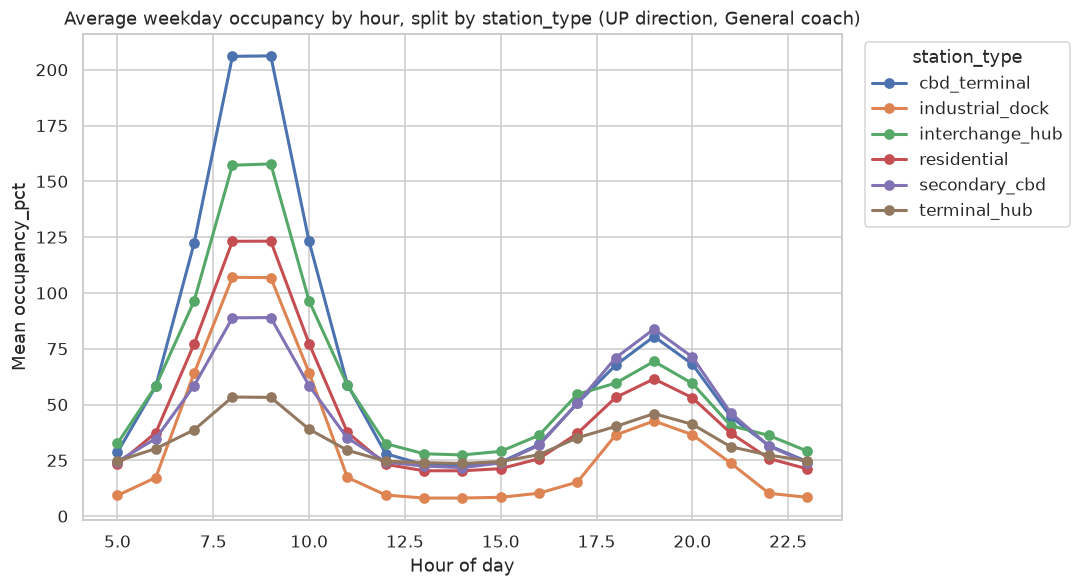

In [7]:
shape_df = df[(df.direction == "UP") & (df.coach_type == "General")
              & (~df.is_weekend) & (~df.is_holiday)]
pivot = shape_df.pivot_table(index="hour", columns="station_type", values="occupancy_pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 5.5))
pivot.plot(ax=ax, marker="o", linewidth=2)
ax.set_title("Average weekday occupancy by hour, split by station_type (UP direction, General coach)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean occupancy_pct")
ax.legend(title="station_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/04_station_type_signatures.png", bbox_inches="tight")
plt.show()

## 6. Weekday vs weekend vs holiday, and the mega-block effect

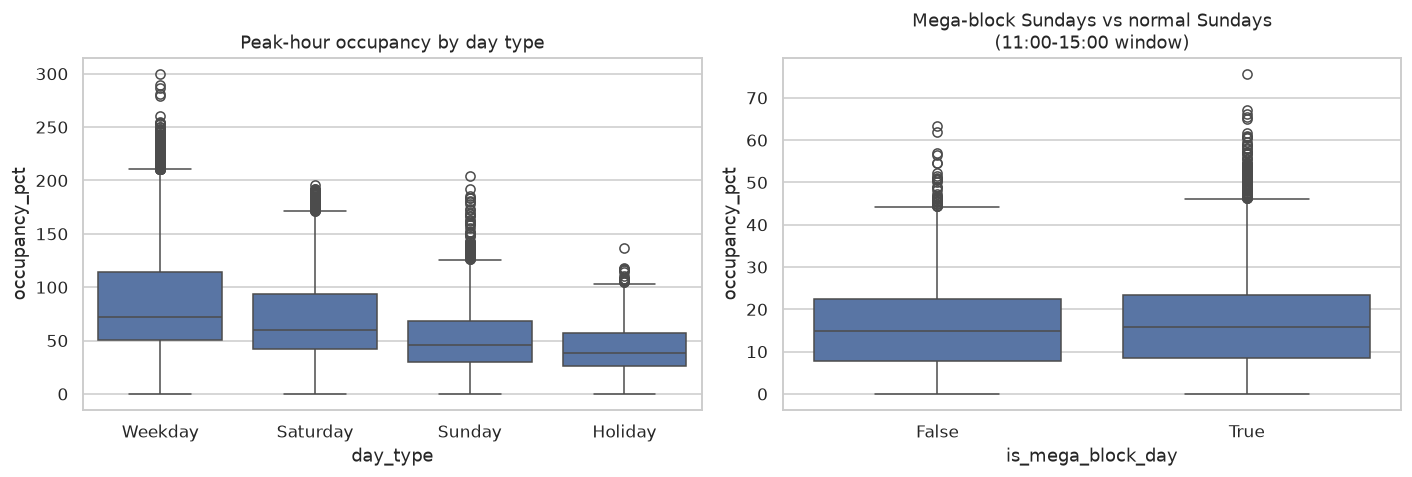

In [8]:
day_type = df.copy()
day_type["day_type"] = np.select(
    [day_type.is_holiday, day_type.day_of_week == "Sunday", day_type.day_of_week == "Saturday"],
    ["Holiday", "Sunday", "Saturday"],
    default="Weekday",
)
peak_only = day_type[(day_type.hour.isin([8, 19])) & (day_type.coach_type == "General")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=peak_only, x="day_type", y="occupancy_pct", ax=axes[0],
            order=["Weekday", "Saturday", "Sunday", "Holiday"])
axes[0].set_title("Peak-hour occupancy by day type")

block_cmp = df[(df.day_of_week == "Sunday") & (df.hour.between(11, 15))
               & (df.coach_type == "General")]
sns.boxplot(data=block_cmp, x="is_mega_block_day", y="occupancy_pct", ax=axes[1])
axes[1].set_title("Mega-block Sundays vs normal Sundays\n(11:00-15:00 window)")
axes[1].set_xlabel("is_mega_block_day")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/05_day_type_and_mega_block.png", bbox_inches="tight")
plt.show()

## 7. Weather: monsoon calibration and the disruption effect

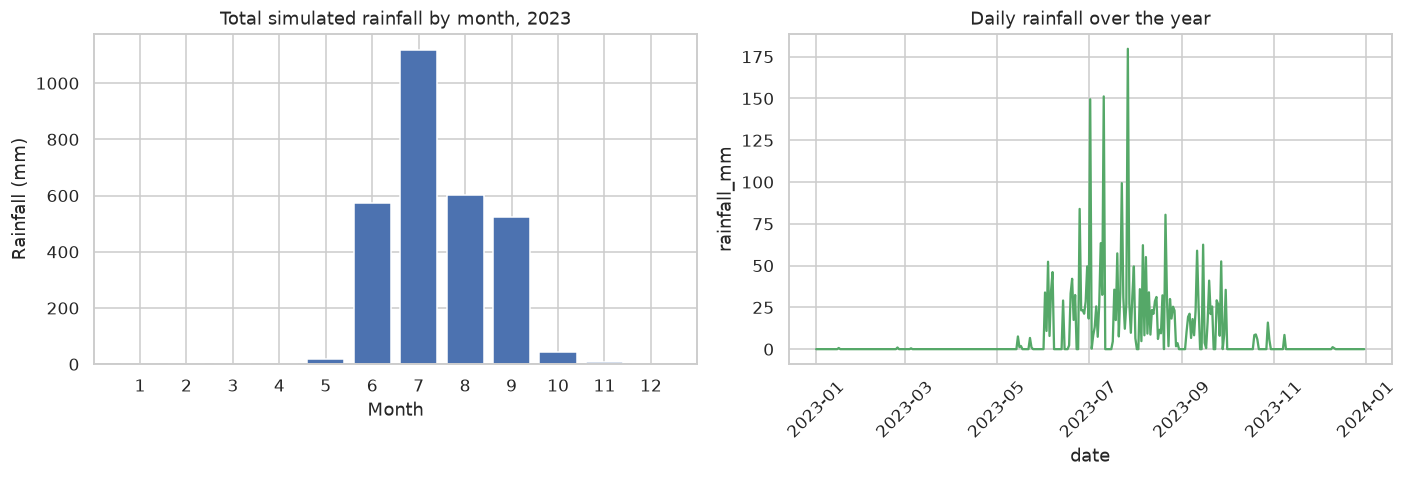

rain_regime
normal                    301
moderate_rain              58
heavy_rain_strained         3
extreme_rain_suspended      3
Name: count, dtype: int64


In [9]:
daily = df.drop_duplicates("date")[["date", "month", "rainfall_mm", "rain_intensity_band", "rain_regime"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

monthly_rain = daily.groupby("month")["rainfall_mm"].sum()
axes[0].bar(monthly_rain.index, monthly_rain.values, color="#4C72B0")
axes[0].set_title("Total simulated rainfall by month, 2023")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].set_xticks(range(1, 13))

sns.lineplot(data=daily.sort_values("date"), x="date", y="rainfall_mm", ax=axes[1], color="#55A868")
axes[1].set_title("Daily rainfall over the year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/06_rainfall_calibration.png", bbox_inches="tight")
plt.show()

print(daily["rain_regime"].value_counts())

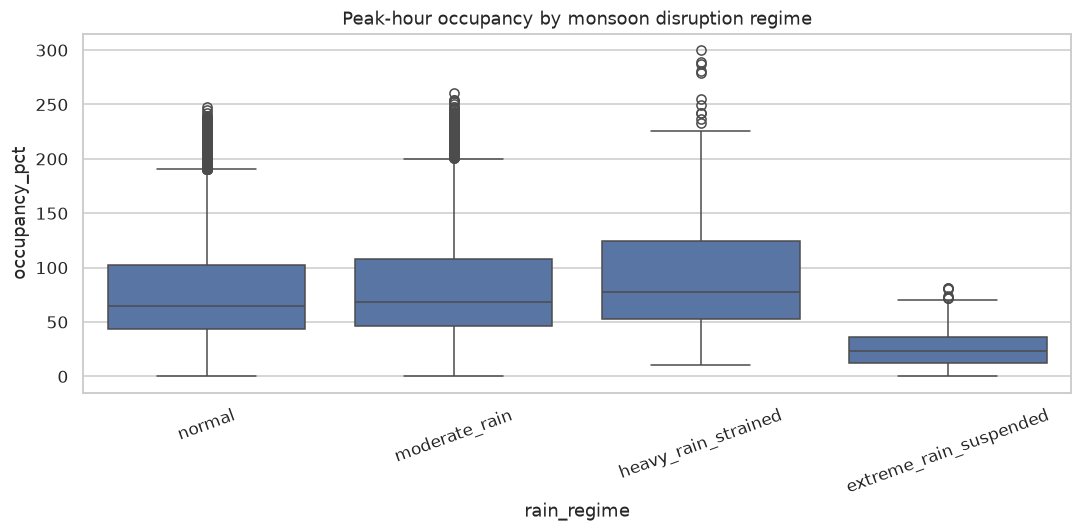

In [10]:
peak_rain = df[(df.hour.isin([8, 19])) & (df.coach_type == "General")]
order = ["normal", "moderate_rain", "heavy_rain_strained", "heavy_rain_suspended",
         "extreme_rain_strained", "extreme_rain_suspended"]
order = [o for o in order if o in peak_rain["rain_regime"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=peak_rain, x="rain_regime", y="occupancy_pct", order=order, ax=ax)
ax.set_title("Peak-hour occupancy by monsoon disruption regime")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/07_rain_regime_effect.png", bbox_inches="tight")
plt.show()

## 8. Correlation between numeric features

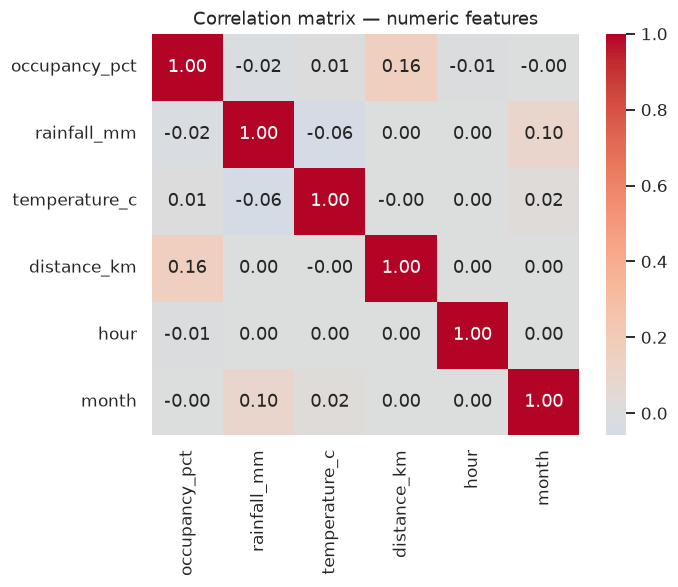

In [11]:
num_cols = ["occupancy_pct", "rainfall_mm", "temperature_c", "distance_km", "hour", "month"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/08_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 9. Summary

- `occupancy_pct` spans 0-300%, with a heavy right-favoring peak-hour mass reflecting
  the real "super-dense crush load" phenomenon on Mumbai's suburban network.
- The AM/DOWN vs PM/UP asymmetry and the CSMT-to-Panvel load buildup both come out
  exactly as designed (§3-4 of `DATA_GENERATION.md`), confirming the simulator's
  direction/distance logic is behaving correctly.
- `station_type` produces visibly distinct daily shapes (§5) — this is the signal
  Phase 2's K-means/hierarchical clustering will need to recover from the raw
  per-station hourly profile, without being told the station types directly.
- Weekday > Saturday > Sunday > Holiday ordering holds at peak hours, and mega-block
  Sundays show a clear crowding spike in the 11:00-15:00 block window relative to
  ordinary Sundays.
- Monsoon rainfall lands close to (not exactly on) the calibrated monthly targets —
  expected for one stochastic year — and the disruption regimes (strained vs
  suspended) produce clearly separated occupancy distributions at peak hours, in both
  directions the brief asked for (crowding *up* from pile-up, crowding *down* from
  suspension).

All figures are saved to `reports/phase1/` for direct reuse in a presentation.

**Next: Phase 2** — cluster stations by their normalized hourly ridership *shape*
(not raw volume) using K-means and hierarchical clustering, and feed the resulting
cluster assignment back in as a feature for Phase 3's regression.